Mounted at /content/drive
=== 1. OVERALL STATISTICAL SUMMARY (N = 279 ZIPs) ===


,mean,std,min,50%,max
pct_area_100yr_flood,4.265233,9.324365,1.0000,1.0000,42.0000
pct_area_coastal_surge,0.862007,3.906247,0.0000,0.0000,18.5000
nfip_total_claims,847.627240,1409.728286,0.0000,286.0000,8374.0000
elec_base_monthly_fee,4.687634,0.971913,4.3900,4.3900,7.8500
elec_delivery_rate_per_kwh,0.038797,0.002275,0.0381,0.0381,0.0462
water_base_monthly_fee,20.238710,5.339510,16.8000,16.8000,28.5000
water_rate_per_1k_gal,7.052509,0.935555,6.4500,6.4500,8.5000
gas_distribution_rate_per_ccf,0.093346,0.003331,0.0912,0.0912,0.0985
adj_monthly_food_cost_moderate,1535.000000,0.000000,1535.0000,1535.0000,1535.0000



=== 2. CLUSTER ARCHETYPE COMPARISON TABLE ===


,cost_risk_cluster,cluster_archetype_name,zip_count,avg_100yr_flood,avg_coastal_surge,avg_nfip_claims,mud_prevalence,twia_prevalence,avg_water_base,avg_elec_delivery
0,0,Urban Core / Municipal Stable,193,1.725389,0.0,662.989637,0.000000,0.0,16.800000,0.038100
1,1,Galveston Mainland / Coastal Utility Corridor,14,5.000000,0.0,1434.142857,1.000000,1.0,28.500000,0.046200
2,2,Suburban MUD Growth Corridor,59,4.084746,0.0,618.677966,0.983051,0.0,28.301695,0.038100
3,3,High-Hazard Coastal Surge & Floodplain,13,42.000000,18.5,3996.230769,0.769231,1.0,25.800000,0.044331


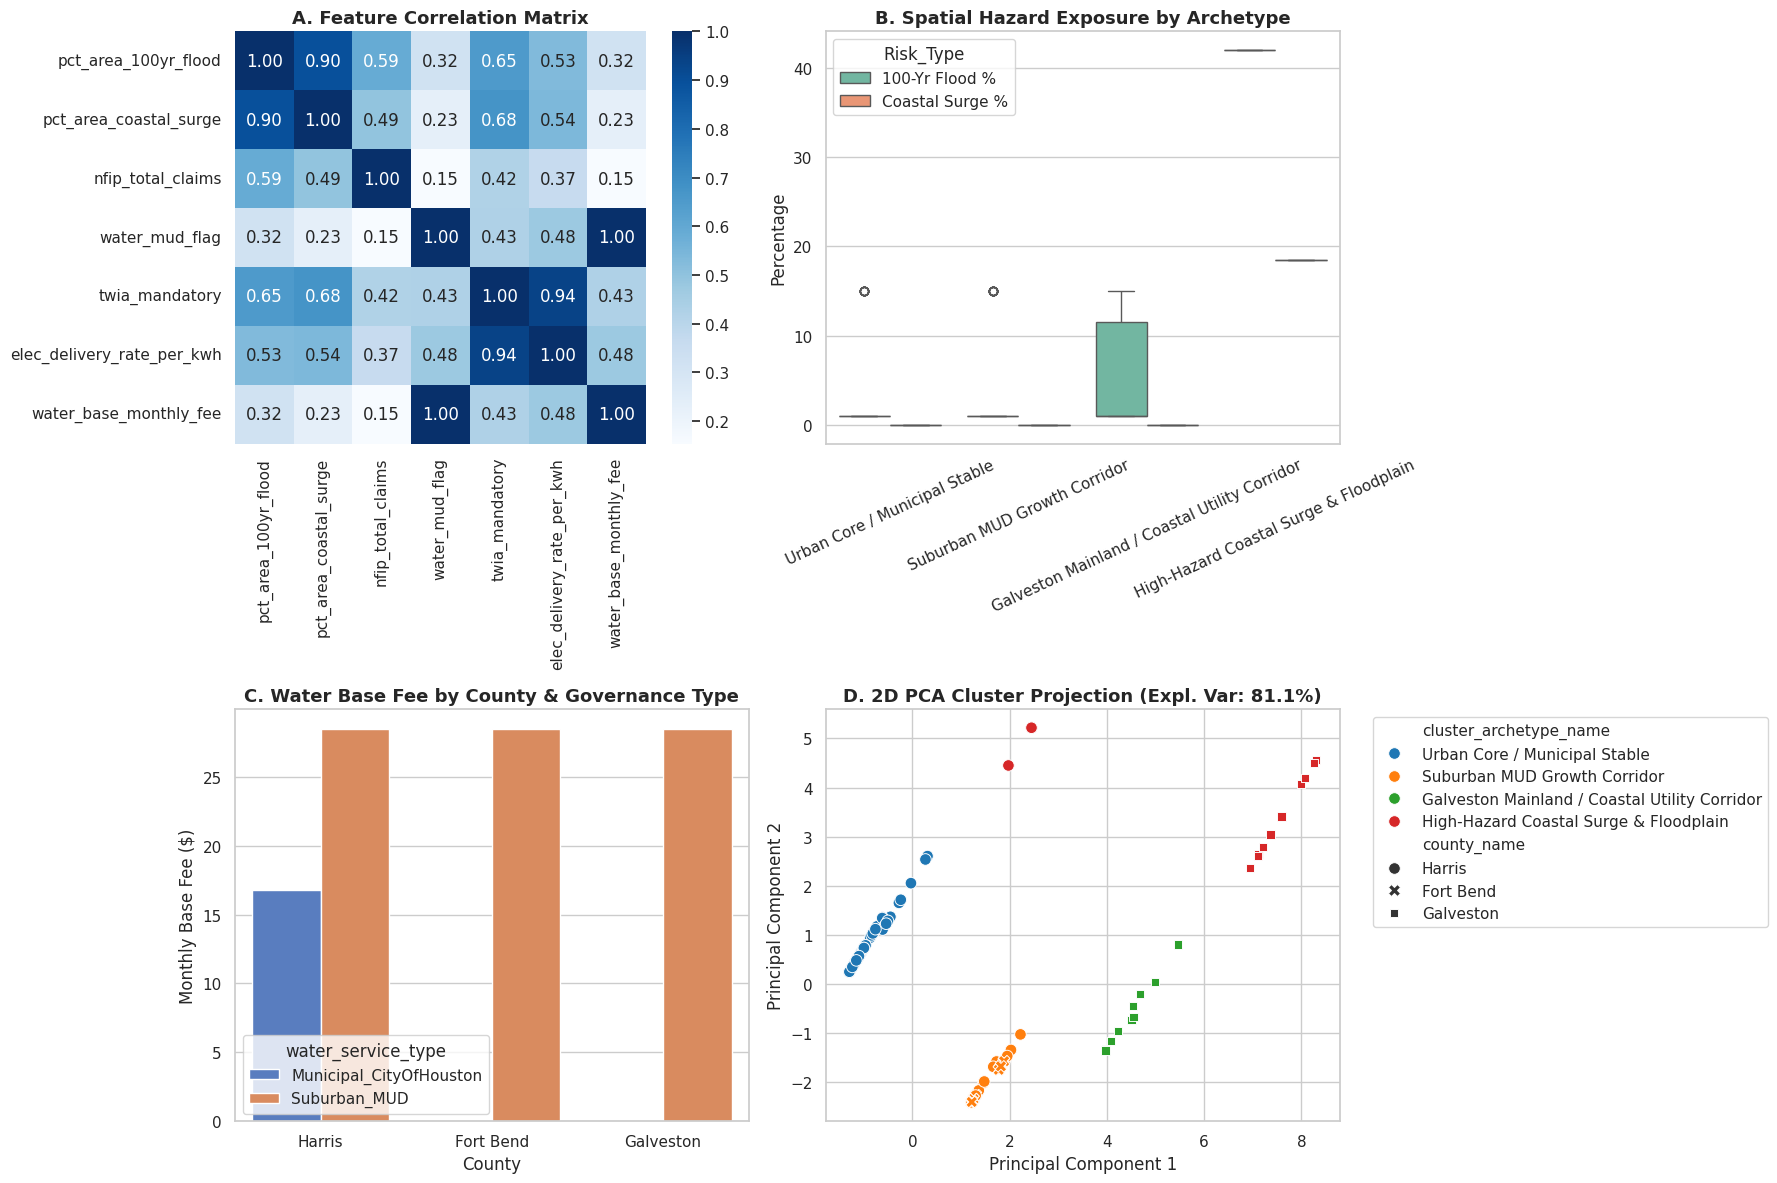

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# 1. Mount Drive & Load Clustered Dataset
drive.mount('/content/drive')
base_dir = '/content/drive/MyDrive/Fall Semester 2026/AI Resource Capstone - 2277/Capstone Shared Folder/Datasets/Cleaned Data'
df = pd.read_parquet(os.path.join(base_dir, 'master_living_costs_clustered.parquet'))
df['zip_code'] = df['zip_code'].astype(str).str.zfill(5)

# 2. Statistical Analysis: Macro Summary Table
print("=== 1. OVERALL STATISTICAL SUMMARY (N = 279 ZIPs) ===")
numeric_metrics = [
    'pct_area_100yr_flood', 'pct_area_coastal_surge', 'nfip_total_claims',
    'elec_base_monthly_fee', 'elec_delivery_rate_per_kwh',
    'water_base_monthly_fee', 'water_rate_per_1k_gal',
    'gas_distribution_rate_per_ccf', 'adj_monthly_food_cost_moderate'
]
display(df[numeric_metrics].describe().T[['mean', 'std', 'min', '50%', 'max']])

# 3. Statistical Analysis: Cluster Archetype Comparison
print("\n=== 2. CLUSTER ARCHETYPE COMPARISON TABLE ===")
cluster_summary = df.groupby(['cost_risk_cluster', 'cluster_archetype_name']).agg(
    zip_count=('zip_code', 'count'),
    avg_100yr_flood=('pct_area_100yr_flood', 'mean'),
    avg_coastal_surge=('pct_area_coastal_surge', 'mean'),
    avg_nfip_claims=('nfip_total_claims', 'mean'),
    mud_prevalence=('water_mud_flag', 'mean'),
    twia_prevalence=('twia_mandatory', 'mean'),
    avg_water_base=('water_base_monthly_fee', 'mean'),
    avg_elec_delivery=('elec_delivery_rate_per_kwh', 'mean')
).reset_index()
display(cluster_summary)

# 4. Visualizations: Set Style
sns.set_theme(style="whitegrid")
fig = plt.figure(figsize=(18, 12))

# Chart A: Correlation Heatmap
ax1 = plt.subplot(2, 2, 1)
corr_cols = [
    'pct_area_100yr_flood', 'pct_area_coastal_surge', 'nfip_total_claims',
    'water_mud_flag', 'twia_mandatory', 'elec_delivery_rate_per_kwh', 'water_base_monthly_fee'
]
corr_matrix = df[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", ax=ax1, cbar=True)
ax1.set_title("A. Feature Correlation Matrix", fontsize=13, fontweight='bold')

# Chart B: Flood & Surge Risk by Cluster Boxplot
ax2 = plt.subplot(2, 2, 2)
df_melted_risk = df.melt(
    id_vars=['cluster_archetype_name'],
    value_vars=['pct_area_100yr_flood', 'pct_area_coastal_surge'],
    var_name='Risk_Type', value_name='Percentage'
)
df_melted_risk['Risk_Type'] = df_melted_risk['Risk_Type'].map({
    'pct_area_100yr_flood': '100-Yr Flood %',
    'pct_area_coastal_surge': 'Coastal Surge %'
})
sns.boxplot(data=df_melted_risk, x='cluster_archetype_name', y='Percentage', hue='Risk_Type', palette='Set2', ax=ax2)
ax2.set_title("B. Spatial Hazard Exposure by Archetype", fontsize=13, fontweight='bold')
ax2.set_xlabel("")
ax2.tick_params(axis='x', rotation=25)

# Chart C: Water Base Fee Disparity (MUD vs Municipal)
ax3 = plt.subplot(2, 2, 3)
sns.barplot(data=df, x='county_name', y='water_base_monthly_fee', hue='water_service_type', palette='muted', ax=ax3)
ax3.set_title("C. Water Base Fee by County & Governance Type", fontsize=13, fontweight='bold')
ax3.set_ylabel("Monthly Base Fee ($)")
ax3.set_xlabel("County")

# Chart D: 2D PCA Cluster Separation
ax4 = plt.subplot(2, 2, 4)
features_for_pca = df[numeric_metrics]
scaled_pca_features = StandardScaler().fit_transform(features_for_pca)
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(scaled_pca_features)

df['pca_dim1'] = pca_coords[:, 0]
df['pca_dim2'] = pca_coords[:, 1]
sns.scatterplot(
    data=df, x='pca_dim1', y='pca_dim2', hue='cluster_archetype_name',
    style='county_name', palette='tab10', s=70, ax=ax4
)
ax4.set_title(f"D. 2D PCA Cluster Projection (Expl. Var: {sum(pca.explained_variance_ratio_)*100:.1f}%)", fontsize=13, fontweight='bold')
ax4.set_xlabel("Principal Component 1")
ax4.set_ylabel("Principal Component 2")
ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [2]:
# BASELINE MODEL COMPARISON

# 1. Establish the Naive Baseline Model (Regional Fixed Average for Family of 4)
# Assumes: Regional average electricity delivery ($0.039/kWh), average water base ($19.50), average food cost ($1535), zero flood surcharge
df['baseline_est_monthly_cost'] = 1535.00 + (df['elec_base_monthly_fee'].mean() + 1400 * df['elec_delivery_rate_per_kwh'].mean()) + \
                                  (df['water_base_monthly_fee'].mean() + 6.8 * df['water_rate_per_1k_gal'].mean()) + \
                                  (df['gas_base_monthly_fee'].mean() + 45 * df['gas_distribution_rate_per_ccf'].mean())

# 2. Granular Clustered Living Cost Engine (Actual Localized Rates & Statutory Fees)
df['granular_food'] = df['adj_monthly_food_cost_moderate']
df['granular_elec'] = df['elec_base_monthly_fee'] + (1400 * df['elec_delivery_rate_per_kwh'])
df['granular_water'] = df['water_base_monthly_fee'] + (6.8 * df['water_rate_per_1k_gal'])
df['granular_gas'] = df['gas_base_monthly_fee'] + (45 * df['gas_distribution_rate_per_ccf'])
df['granular_twia'] = np.where(df['twia_mandatory'] == 1, 175.00, 0.0) # $175/mo mandatory coastal sinking fund

df['granular_actual_monthly_cost'] = df['granular_food'] + df['granular_elec'] + df['granular_water'] + df['granular_gas'] + df['granular_twia']

# 3. Compute Absolute Estimation Variance (The Cost of Naive Modeling)
df['baseline_absolute_error'] = (df['baseline_est_monthly_cost'] - df['granular_actual_monthly_cost']).abs()

print("=== BASELINE VS. GRANULAR MODEL COMPARISON ===")
print(f"Mean Regional Baseline Cost:     ${df['baseline_est_monthly_cost'].iloc[0]:,.2f} / month")
print(f"Actual Localized Cost Range:     ${df['granular_actual_monthly_cost'].min():,.2f} to ${df['granular_actual_monthly_cost'].max():,.2f} / month")
print(f"Mean Absolute Estimation Bias:   ${df['baseline_absolute_error'].mean():,.2f} / month")
print(f"Max Estimation Under/Overcharge: ${df['baseline_absolute_error'].max():,.2f} / month")

print("\n--- Mean Cost Error by Cluster When Using a Naive Baseline ---")
print(df.groupby('cluster_archetype_name')['baseline_absolute_error'].mean().round(2))

=== BASELINE VS. GRANULAR MODEL COMPARISON ===
Mean Regional Baseline Cost:     $1,684.90 / month
Actual Localized Cost Range:     $1,675.99 to $1,891.76 / month
Mean Absolute Estimation Bias:   $29.32 / month
Max Estimation Under/Overcharge: $206.86 / month

--- Mean Cost Error by Cluster When Using a Naive Baseline ---
cluster_archetype_name
Galveston Mainland / Coastal Utility Corridor    206.86
High-Hazard Coastal Surge & Floodplain           197.45
Suburban MUD Growth Corridor                      16.92
Urban Core / Municipal Stable                      8.91
Name: baseline_absolute_error, dtype: float64
